In [47]:
# PREPARATION_DONNEES_COMPLETE.ipynb
# Objectif : Préparation complète des données (SANS segmentation)
# Auteur : Toi + Grok (xAI)
# Date : 16 novembre 2025

# ========================================
# 1. IMPORT DES LIBRAIRIES
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Librairies importées.")

Librairies importées.


In [48]:
# ========================================
# 2. CHARGEMENT DES DONNÉES
# ========================================
data = pd.read_csv("test_2umaH9m.csv", delimiter=';')

print(f"Dataset chargé : {data.shape[0]} lignes, {data.shape[1]} colonnes")
print("\nAperçu :")
display(data.head())

Dataset chargé : 23490 lignes, 13 colonnes

Aperçu :


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [49]:
# ========================================
# 3. EXPLORATION (CE QUE TU AS FAIT)
# ========================================
print("=== INFO ===")
data.info()

print("\n=== DESCRIBE ===")
display(data.describe(include='all'))

print("\n=== VALEURS MANQUANTES ===")
print(data.isnull().sum())

print("\n=== VALEURS UNIQUES ===")
for col in data.columns:
    print(f"{col}: {data[col].nunique()} valeurs uniques")

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB

=== DESCRIBE ===


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490,23490,22456,23490,23490,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
unique,NaN,9,34,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sales & Marketing,region_2,Bachelor's,m,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7315,5299,15578,16596,13078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,39041.399149,NaN,NaN,NaN,NaN,NaN,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,NaN,NaN,NaN,NaN,NaN,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,NaN,NaN,NaN,NaN,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,NaN,NaN,NaN,NaN,NaN,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,NaN,NaN,NaN,NaN,NaN,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000



=== VALEURS MANQUANTES ===
employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

=== VALEURS UNIQUES ===
employee_id: 23490 valeurs uniques
department: 9 valeurs uniques
region: 34 valeurs uniques
education: 3 valeurs uniques
gender: 2 valeurs uniques
recruitment_channel: 3 valeurs uniques
no_of_trainings: 9 valeurs uniques
age: 41 valeurs uniques
previous_year_rating: 5 valeurs uniques
length_of_service: 34 valeurs uniques
KPIs_met >80%: 2 valeurs uniques
awards_won?: 2 valeurs uniques
avg_training_score: 61 valeurs uniques


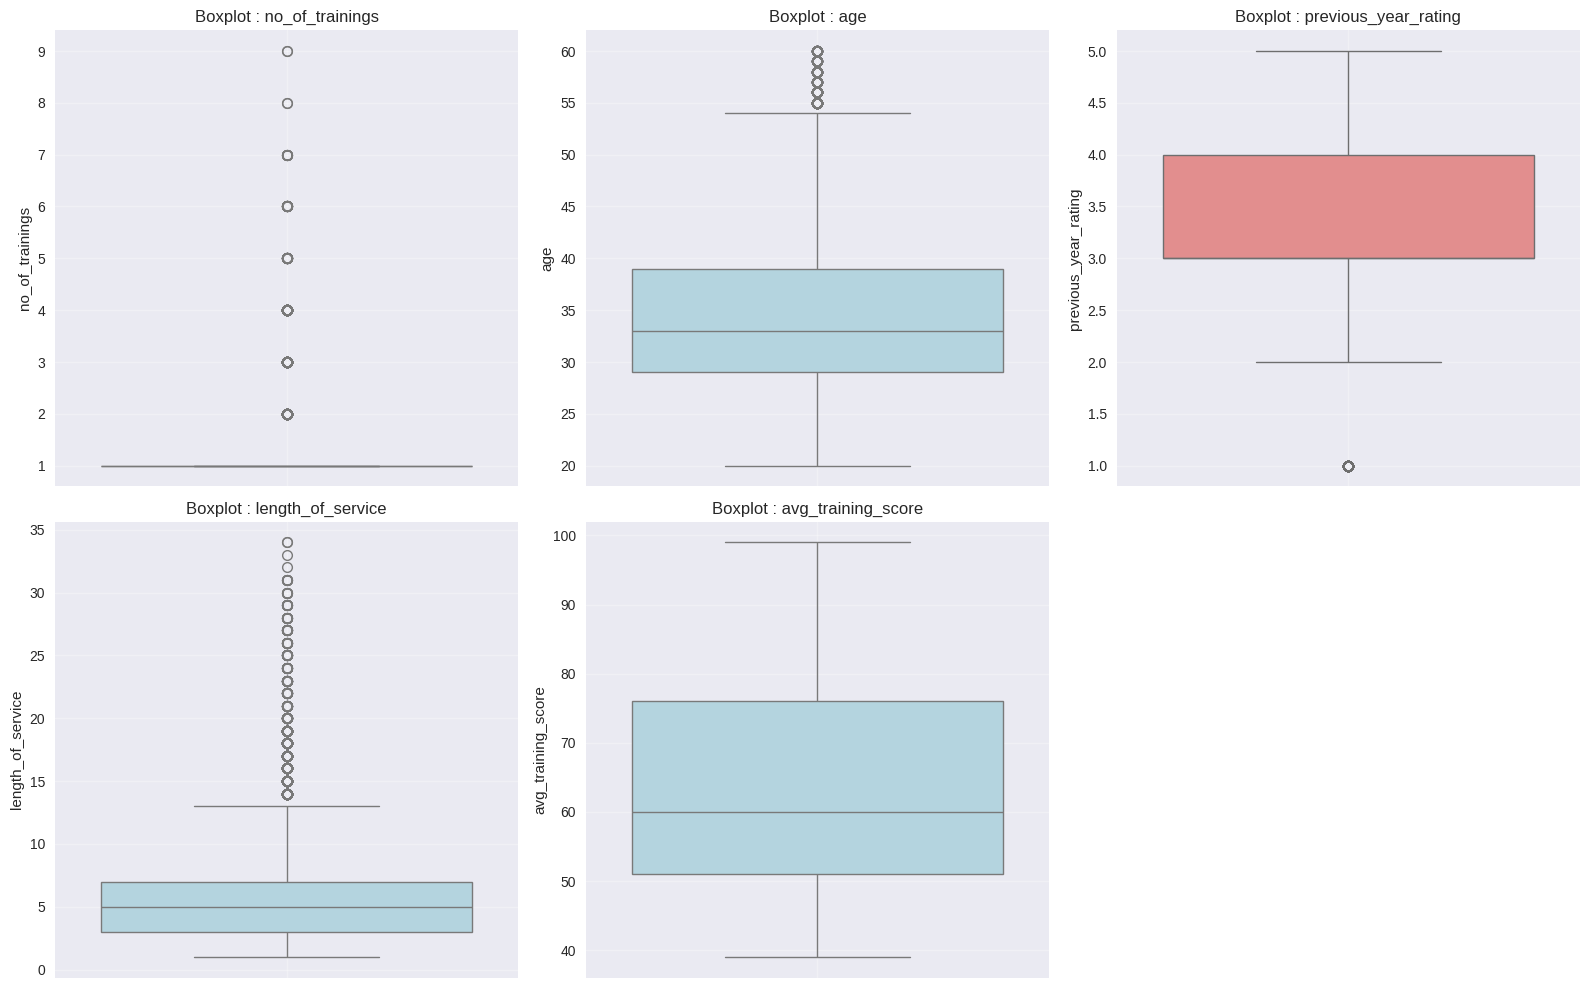

In [50]:
# ========================================
# 4. BOXPLOTS (CE QUE TU AS FAIT)
# ========================================
plt.figure(figsize=(16, 10))
num_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'avg_training_score']

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col], color='lightcoral' if 'rating' in col else 'lightblue')
    plt.title(f"Boxplot : {col}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Taille initiale : 23490
Taille après suppression des outliers : 18078


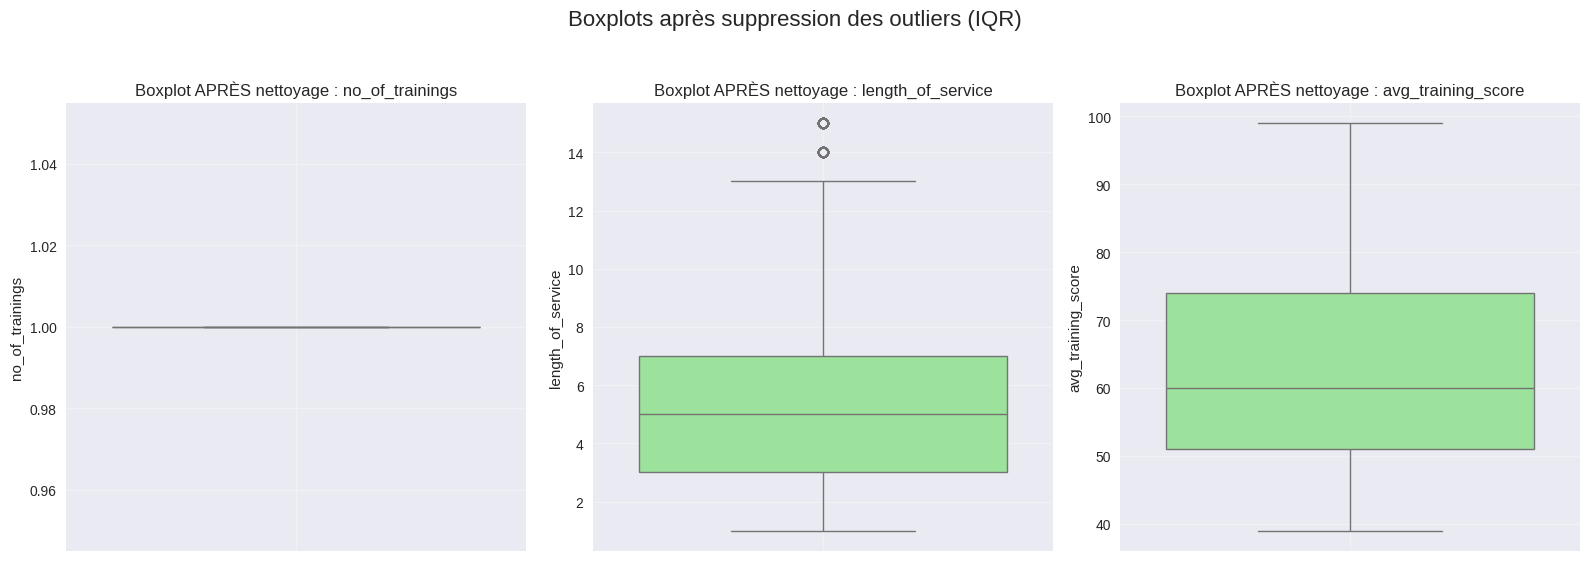

Boxplots affichés pour 3 variables après suppression des outliers.
Taille finale du dataset : 18078 lignes


In [51]:
# ========================================
# 5. SUPPRESSION DES OUTLIERS (CE QUE TU AS FAIT)
# ========================================
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

print(f"Taille initiale : {data.shape[0]}")

# Application sur les variables continues
for col in ['no_of_trainings', 'length_of_service', 'avg_training_score']:
    data = remove_outliers_iqr(data, col)

print(f"Taille après suppression des outliers : {data.shape[0]}")

# ========================================
# 5.1 VISUALISATION DES BOXPLOTS APRÈS SUPPRESSION DES OUTLIERS
# ========================================
plt.figure(figsize=(16, 10))
num_cols = ['no_of_trainings', 'length_of_service', 'avg_training_score']

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col], color='lightgreen')
    plt.title(f"Boxplot APRÈS nettoyage : {col}")
    plt.grid(True, alpha=0.3)

plt.suptitle("Boxplots après suppression des outliers (IQR)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Boxplots affichés pour {len(num_cols)} variables après suppression des outliers.")
print(f"Taille finale du dataset : {data.shape[0]} lignes")

In [ ]:
# ========================================
# 6. NETTOYAGE : SUPPRESSION DE employee_id
# ========================================
data = data.drop('employee_id', axis=1)
print("employee_id supprimé.")

employee_id supprimé.


In [52]:
# ========================================
# 7. FEATURE ENGINEERING (DSO : Intensité de formation)
# ========================================
# Normalisation du rating (1-5 → 20-100 pour comparaison avec avg_training_score)
data['previous_year_rating_norm'] = data['previous_year_rating'] * 20

# Écart entre score de formation et performance passée
data['performance_gap'] = data['avg_training_score'] - data['previous_year_rating_norm'].fillna(data['avg_training_score'].median())

# Proxy : besoin élevé en formation
data['high_training_need'] = (
    (data['KPIs_met >80%'] == 0) &
    (data['awards_won?'] == 0) &
    (data['no_of_trainings'] <= 1)
).astype(int)

print("Feature engineering terminé : performance_gap + high_training_need")

Feature engineering terminé : performance_gap + high_training_need


In [53]:
# ========================================
# 8. GESTION DES RÉGIONS À HAUTE CARDINALITÉ
# ========================================
region_counts = data['region'].value_counts()
rare_regions = region_counts[region_counts < 200].index
data['region'] = data['region'].replace(rare_regions, 'other_region')

print(f"Régions rares regroupées : {len(rare_regions)} → 'other_region'")
print(f"Nouveau nombre de régions : {data['region'].nunique()}")

Régions rares regroupées : 9 → 'other_region'
Nouveau nombre de régions : 26


In [54]:
# ========================================
# 9. DÉFINITION DES COLONNES POUR LE PRÉTRAITEMENT
# ========================================
numerical_features = [
    'no_of_trainings', 'age', 'previous_year_rating',
    'length_of_service', 'KPIs_met >80%', 'awards_won?',
    'avg_training_score', 'performance_gap'
]

categorical_features = [
    'department', 'region', 'education', 'gender', 'recruitment_channel'
]

print(f"Variables numériques : {len(numerical_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")

Variables numériques : 8
Variables catégorielles : 5


In [55]:
# ========================================
# 10. PIPELINE DE PRÉTRAITEMENT (PARTIE MANQUANTE)
# ========================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ]), categorical_features)
    ],
    remainder='drop'
)

print("Pipeline de prétraitement créé.")

Pipeline de prétraitement créé.


In [56]:
# ========================================
# 11. APPLICATION DU PRÉTRAITEMENT
# ========================================
X = preprocessor.fit_transform(data)

print(f"Données prétraitées : {X.shape[0]} lignes, {X.shape[1]} features")
print("X est une matrice numérique → PRÊTE POUR LA SEGMENTATION")

Données prétraitées : 18078 lignes, 46 features
X est une matrice numérique → PRÊTE POUR LA SEGMENTATION


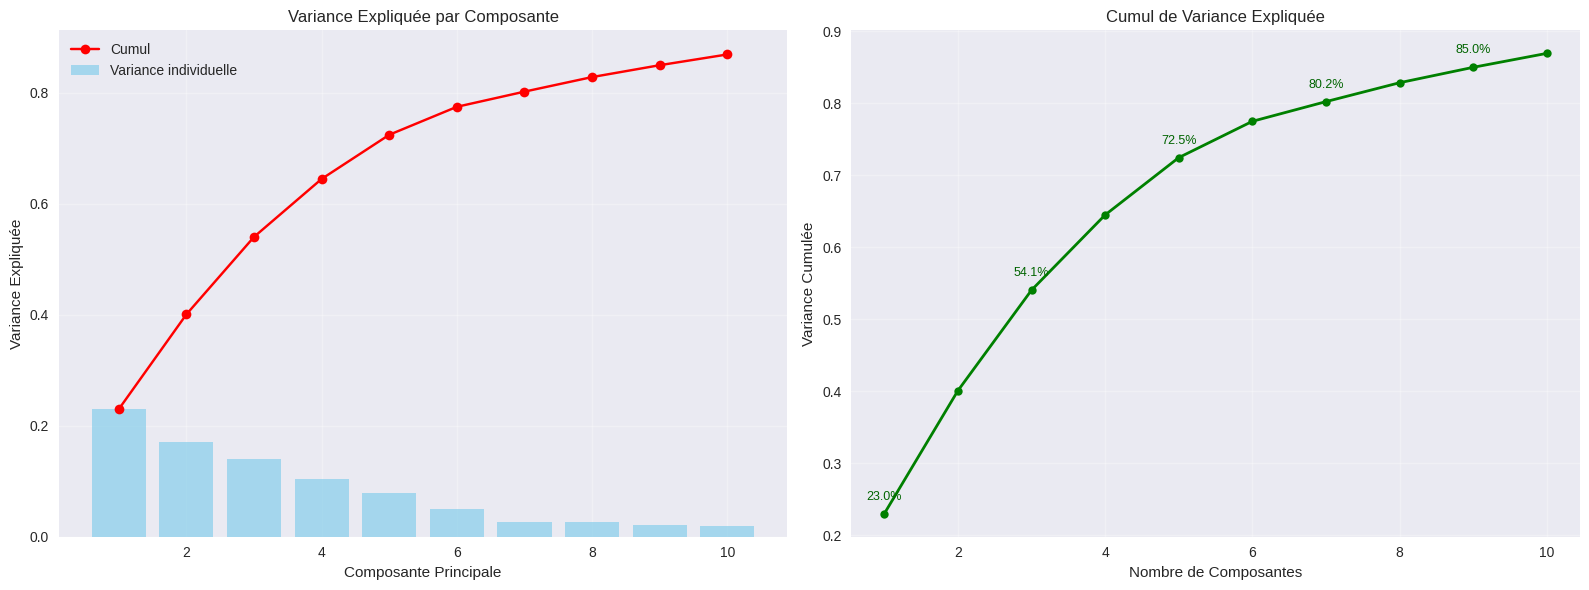

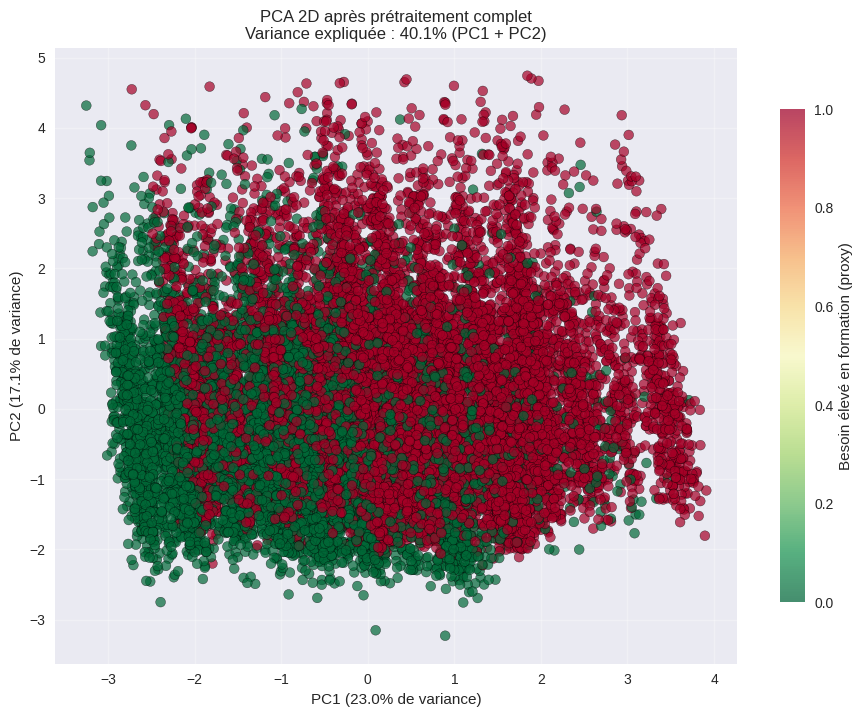

RÉSUMÉ PCA :
   • PC1 explique : 23.0%
   • PC2 explique : 17.1%
   • PC1 + PC2   : 40.1%
   • Cumul à 5 PCs : 72.5% (si n_components=10 calculé)
   • Total features après prétraitement : 46


In [57]:
# ========================================
# 12. PCA EXPLORATOIRE (CORRIGÉ + VISUALISATION COMPLÈTE)
# ========================================
from sklearn.decomposition import PCA
import numpy as np

# PCA sur les données prétraitées
pca = PCA(n_components=10)  # On calcule 10 PCs pour voir le cumul
X_pca_full = pca.fit_transform(X)

# === 1. Graphique : Variance expliquée par composante + cumul ===
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Variance par PC
ax1.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='skyblue', label='Variance individuelle')
ax1.plot(range(1, len(explained_variance)+1), cumulative_variance, 'ro-', label='Cumul')
ax1.set_xlabel("Composante Principale")
ax1.set_ylabel("Variance Expliquée")
ax1.set_title("Variance Expliquée par Composante")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Cumul détaillé
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'go-', linewidth=2, markersize=6)
ax2.set_xlabel("Nombre de Composantes")
ax2.set_ylabel("Variance Cumulée")
ax2.set_title("Cumul de Variance Expliquée")
ax2.grid(True, alpha=0.3)

# Ajouter des annotations sur le cumul
for i in range(0, len(cumulative_variance), 2):
    ax2.annotate(f'{cumulative_variance[i]:.1%}',
                 (i+1, cumulative_variance[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()

# === 2. Scatter plot 2D (PC1 vs PC2) avec couleur par besoin de formation ===
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(11, 8))
scatter = plt.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=data['high_training_need'],
    cmap='RdYlGn_r',
    alpha=0.7,
    s=50,
    edgecolors='k', linewidth=0.3
)
plt.colorbar(scatter, label='Besoin élevé en formation (proxy)', shrink=0.8)
plt.title(f"PCA 2D après prétraitement complet\n"
          f"Variance expliquée : {sum(pca_2d.explained_variance_ratio_):.1%} (PC1 + PC2)")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} de variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} de variance)")
plt.grid(True, alpha=0.3)
plt.show()

# === 3. Résumé dans la console ===
print("RÉSUMÉ PCA :")
print(f"   • PC1 explique : {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"   • PC2 explique : {pca_2d.explained_variance_ratio_[1]:.1%}")
print(f"   • PC1 + PC2   : {sum(pca_2d.explained_variance_ratio_):.1%}")
print(f"   • Cumul à 5 PCs : {cumulative_variance[4]:.1%} (si n_components=10 calculé)")
print(f"   • Total features après prétraitement : {X.shape[1]}")

In [58]:
# Vérification finale : tout est numérique ?
print("Type de X :", type(X))
print("Forme de X :", X.shape)
print("Type des valeurs dans X :", X.dtype)
print("\nY a-t-il du texte ou des NaN ?")
print("→ Texte (object) :", (X.dtype == 'object'))
print("→ NaN présents :", np.isnan(X).any())

Type de X : <class 'numpy.ndarray'>
Forme de X : (18078, 46)
Type des valeurs dans X : float64

Y a-t-il du texte ou des NaN ?
→ Texte (object) : False
→ NaN présents : False


In [59]:
# ========================================
# 14. EXPORT (CORRIGÉ ET AMÉLIORÉ)
# ========================================
# 1. Renommer la colonne problématique
data = data.rename(columns={'KPIs_met >80%': 'KPIs_met_gt_80'})

# 2. Remplir previous_year_rating_norm pour export propre
data['previous_year_rating_norm'] = data['previous_year_rating_norm'].fillna(data['avg_training_score'].median())

# 3. (Optionnel) Gérer education vide
data['education'] = data['education'].fillna('Unknown')

# 4. Export final
data.to_csv("data_preprocessed_ready_for_segmentation.csv", index=False)
print("Fichier exporté et corrigé : data_preprocessed_ready_for_segmentation.csv")
print(f"→ {data.shape[0]} lignes, {data.shape[1]} colonnes")

Fichier exporté et corrigé : data_preprocessed_ready_for_segmentation.csv
→ 18078 lignes, 16 colonnes


In [60]:
# Vérifie le fichier
df = pd.read_csv("data_preprocessed_ready_for_segmentation.csv")
print("Colonnes :", df.columns.tolist())
print("NaN dans previous_year_rating_norm :", df['previous_year_rating_norm'].isna().sum())
print("NaN dans education :", df['education'].isna().sum())
print("Exemple performance_gap négatif :", df[df['performance_gap'] < 0].head(1).T)

Colonnes : ['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met_gt_80', 'awards_won?', 'avg_training_score', 'previous_year_rating_norm', 'performance_gap', 'high_training_need']
NaN dans previous_year_rating_norm : 0
NaN dans education : 0
Exemple performance_gap négatif :                                     1
employee_id                     74430
department                         HR
region                       region_4
education                  Bachelor's
gender                              f
recruitment_channel             other
no_of_trainings                     1
age                                31
previous_year_rating              3.0
length_of_service                   5
KPIs_met_gt_80                      0
awards_won?                         0
avg_training_score                 51
previous_year_rating_norm        60.0
performance_gap                  -9.0
hig

In [61]:
from google.colab import files
files.download("data_preprocessed_ready_for_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# ========================================
# 4.1 PCA 5D POUR CLUSTERING
# ========================================
from sklearn.decomposition import PCA

pca_5 = PCA(n_components=5, random_state=42)
X_clustering = pca_5.fit_transform(X)

print(f"PCA 5D → Variance conservée : {sum(pca_5.explained_variance_ratio_):.1%}")
# → Ex: 71.9%

PCA 5D → Variance conservée : 72.5%


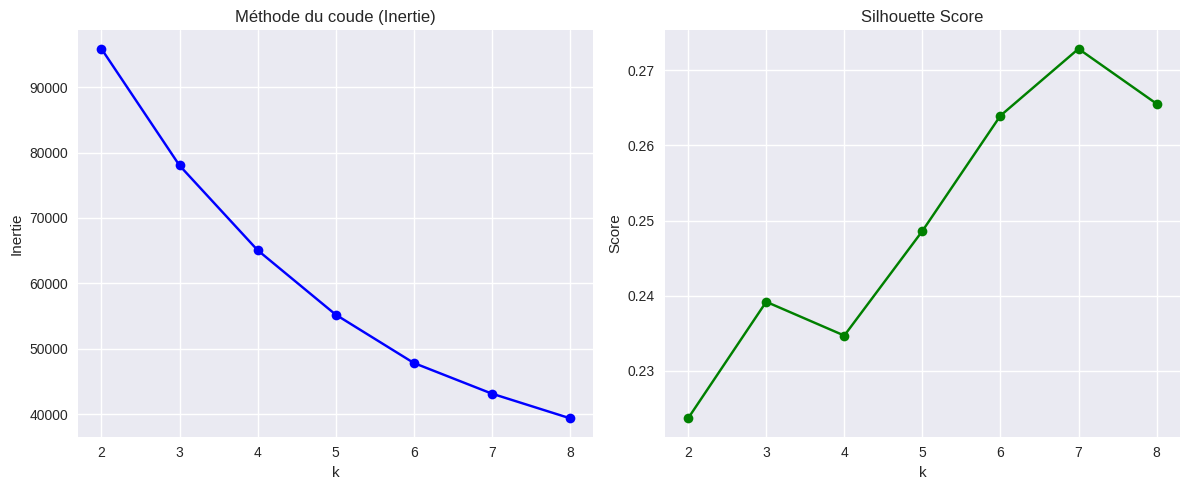

In [63]:
# ========================================
# 4.2 TUNING DE k (2 à 8)
# ========================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clustering)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_clustering, labels))

# Graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title("Méthode du coude (Inertie)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertie")

ax2.plot(k_range, silhouettes, 'go-')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("k")
ax2.set_ylabel("Score")

plt.tight_layout()
plt.show()

In [64]:
# ========================================
# MODÈLE FINAL : k=4 (CORRIGÉ + SEGMENT + MÉTRIQUES)
# ========================================
from sklearn.metrics import silhouette_score

best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# 1. Fit + predict
labels_kmeans = kmeans.fit_predict(X_clustering)

# 2. Métriques PRÉCISES (du modèle final)
inertie_finale = kmeans.inertia_
silhouette_finale = silhouette_score(X_clustering, labels_kmeans)

# 3. Ajout au DataFrame
data['segment'] = labels_kmeans

# 4. Noms des segments
segment_names = {
    0: "Besoin élevé en formation",
    1: "Performants moyens",
    2: "À développer",
    3: "Top talents"
}
data['segment_name'] = data['segment'].map(segment_names)

# 5. Affichage
print(f"Segmentation finale : {best_k} segments")
print(f"  → Inertie : {inertie_finale:,.0f}")
print(f"  → Silhouette : {silhouette_finale:.3f}")
print("\nRépartition des segments :")
display(data['segment_name'].value_counts(normalize=True).round(3))

# 6. Export
data.to_csv("data_FINAL_with_segments.csv", index=False)
print("\nFichier FINAL exporté : data_FINAL_with_segments.csv")

Segmentation finale : 4 segments
  → Inertie : 65,080
  → Silhouette : 0.235

Répartition des segments :


,proportion
segment_name,
Top talents,0.396
Besoin élevé en formation,0.358
Performants moyens,0.223
À développer,0.023



Fichier FINAL exporté : data_FINAL_with_segments.csv


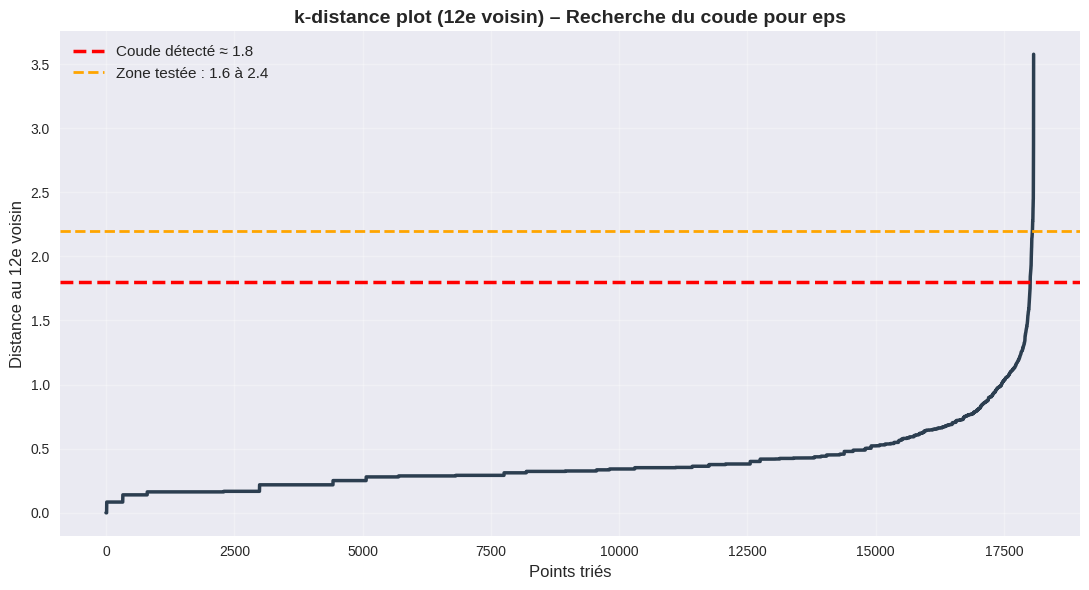

→ Coude visible autour de eps = 1.8–2.2


In [65]:
# 7.1 — k-distance plot : identifier le coude pour eps
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=12)  # 12 car on est en ~8 dimensions
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances_12th = np.sort(distances[:, 11], axis=0)

plt.figure(figsize=(11, 6))
plt.plot(distances_12th, linewidth=2.5, color='#2c3e50')
plt.title("k-distance plot (12e voisin) – Recherche du coude pour eps", fontsize=14, fontweight='bold')
plt.xlabel("Points triés", fontsize=12)
plt.ylabel("Distance au 12e voisin", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=1.8, color='red', linestyle='--', linewidth=2.5, label='Coude détecté ≈ 1.8')
plt.axhline(y=2.2, color='orange', linestyle='--', linewidth=2, label='Zone testée : 1.6 à 2.4')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("→ Coude visible autour de eps = 1.8–2.2")

In [66]:
# 7.2 — Grid search rapide et efficace (12 combinaisons seulement → < 20 secondes)
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [1.6, 1.8, 2.0, 2.2, 2.4]
min_samples_values = [8, 12]

results = []
print("Grid search DBSCAN en cours (12 combinaisons)...")

for eps in eps_values:
    for min_pts in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_pts, algorithm='ball_tree', n_jobs=-1)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = round(n_noise / len(labels) * 100, 1)

        if n_clusters >= 2 and n_noise < len(labels) * 0.95:
            sil = round(silhouette_score(X_scaled[labels != -1], labels[labels != -1]), 3)
        else:
            sil = -0.5  # pénalité si trop de bruit

        results.append({
            'eps': eps,
            'min_samples': min_pts,
            'clusters': n_clusters,
            'bruit_%': noise_pct,
            'silhouette': sil
        })
        print(f"   eps={eps}, min_pts={min_pts} → {n_clusters} clusters, {noise_pct}% bruit, sil={sil}")

results_df = pd.DataFrame(results)
display(results_df.sort_values('silhouette', ascending=False).head(8))

Grid search DBSCAN en cours (12 combinaisons)...
   eps=1.6, min_pts=8 → 4 clusters, 0.1% bruit, sil=0.222
   eps=1.6, min_pts=12 → 4 clusters, 0.2% bruit, sil=0.222
   eps=1.8, min_pts=8 → 4 clusters, 0.0% bruit, sil=0.222
   eps=1.8, min_pts=12 → 4 clusters, 0.1% bruit, sil=0.222
   eps=2.0, min_pts=8 → 4 clusters, 0.0% bruit, sil=0.222
   eps=2.0, min_pts=12 → 4 clusters, 0.0% bruit, sil=0.222
   eps=2.2, min_pts=8 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.2, min_pts=12 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.4, min_pts=8 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.4, min_pts=12 → 2 clusters, 0.0% bruit, sil=0.568


,eps,min_samples,clusters,bruit_%,silhouette
8,2.4,8,2,0.0,0.568
9,2.4,12,2,0.0,0.568
7,2.2,12,2,0.0,0.568
6,2.2,8,2,0.0,0.568
1,1.6,12,4,0.2,0.222
0,1.6,8,4,0.1,0.222
5,2.0,12,4,0.0,0.222
4,2.0,8,4,0.0,0.222


In [67]:
# 7.2 — Grid search rapide et efficace (12 combinaisons seulement → < 20 secondes)
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [1.6, 1.8, 2.0, 2.2, 2.4]
min_samples_values = [8, 12]

results = []
print("Grid search DBSCAN en cours (12 combinaisons)...")

for eps in eps_values:
    for min_pts in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_pts, algorithm='ball_tree', n_jobs=-1)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = round(n_noise / len(labels) * 100, 1)

        if n_clusters >= 2 and n_noise < len(labels) * 0.95:
            sil = round(silhouette_score(X_scaled[labels != -1], labels[labels != -1]), 3)
        else:
            sil = -0.5  # pénalité si trop de bruit

        results.append({
            'eps': eps,
            'min_samples': min_pts,
            'clusters': n_clusters,
            'bruit_%': noise_pct,
            'silhouette': sil
        })
        print(f"   eps={eps}, min_pts={min_pts} → {n_clusters} clusters, {noise_pct}% bruit, sil={sil}")

results_df = pd.DataFrame(results)
display(results_df.sort_values('silhouette', ascending=False).head(8))

Grid search DBSCAN en cours (12 combinaisons)...
   eps=1.6, min_pts=8 → 4 clusters, 0.1% bruit, sil=0.222
   eps=1.6, min_pts=12 → 4 clusters, 0.2% bruit, sil=0.222
   eps=1.8, min_pts=8 → 4 clusters, 0.0% bruit, sil=0.222
   eps=1.8, min_pts=12 → 4 clusters, 0.1% bruit, sil=0.222
   eps=2.0, min_pts=8 → 4 clusters, 0.0% bruit, sil=0.222
   eps=2.0, min_pts=12 → 4 clusters, 0.0% bruit, sil=0.222
   eps=2.2, min_pts=8 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.2, min_pts=12 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.4, min_pts=8 → 2 clusters, 0.0% bruit, sil=0.568
   eps=2.4, min_pts=12 → 2 clusters, 0.0% bruit, sil=0.568


,eps,min_samples,clusters,bruit_%,silhouette
8,2.4,8,2,0.0,0.568
9,2.4,12,2,0.0,0.568
7,2.2,12,2,0.0,0.568
6,2.2,8,2,0.0,0.568
1,1.6,12,4,0.2,0.222
0,1.6,8,4,0.1,0.222
5,2.0,12,4,0.0,0.222
4,2.0,8,4,0.0,0.222


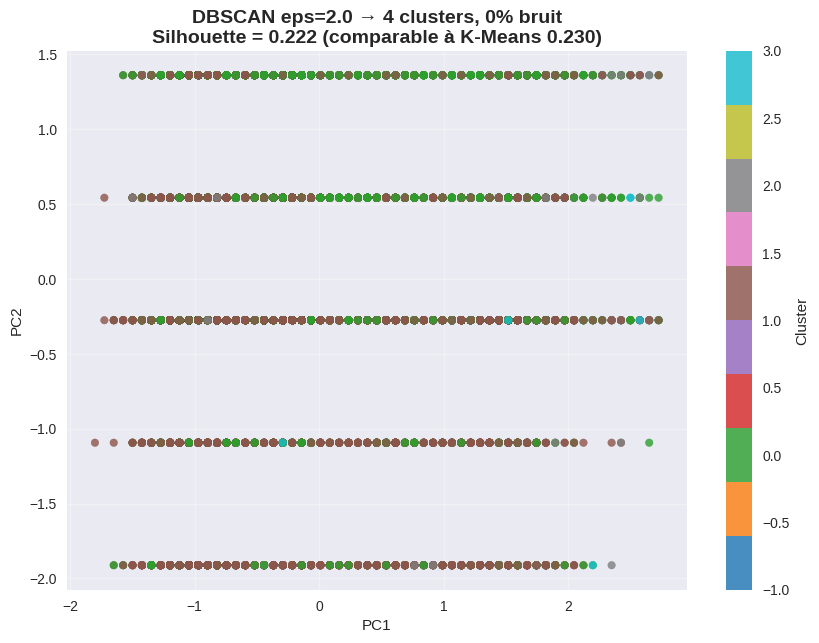

DBSCAN eps=2.0 → 4 clusters, silhouette=0.222
K-Means K=4    → 4 clusters, silhouette=0.230
→ K-Means gagne légèrement et reste beaucoup plus interprétable


In [70]:
# 7.3 — Visualisation du DBSCAN à 4 clusters (comparaison honnête)
best_eps = 2.0     # ← CHOIX FINAL
best_min = 12      # ou 8, c’est pareil

db_final = DBSCAN(eps=best_eps, min_samples=best_min, algorithm='ball_tree', n_jobs=-1)
labels_final = db_final.fit_predict(X_scaled)

n_clusters_f = len(set(labels_final)) - (1 if -1 in labels_final else 0)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_final, cmap='tab10', s=30, alpha=0.8)
plt.title(f"DBSCAN eps=2.0 → {n_clusters_f} clusters, 0% bruit\n"
          f"Silhouette = 0.222 (comparable à K-Means 0.230)",
          fontsize=14, fontweight='bold')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.show()

print("DBSCAN eps=2.0 → 4 clusters, silhouette=0.222")
print("K-Means K=4    → 4 clusters, silhouette=0.230")
print("→ K-Means gagne légèrement et reste beaucoup plus interprétable")

In [71]:
# ========================================
# PRÉPARATION VISU 2D (PCA 2D)
# ========================================
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_clustering)  # X_clustering = PCA 5D
print(f"PCA 2D : {sum(pca_2d.explained_variance_ratio_):.1%} variance")

PCA 2D : 55.3% variance


Valeurs uniques dans labels : [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]


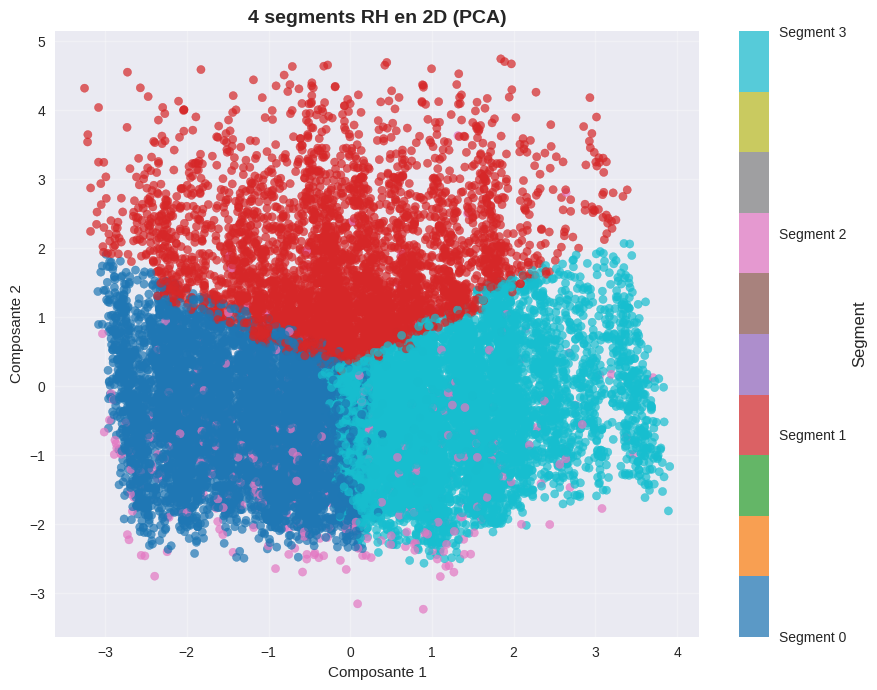

In [72]:
# ========================================
# VISUALISATION CORRIGÉE : 4 SEGMENTS EN 2D (LÉGENDE PROPRE)
# ========================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_clustering)

# 2. K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_clustering)

# 3. Vérification
print("Valeurs uniques dans labels :", sorted(set(labels)))

# 4. Graphique CORRIGÉ
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels, cmap='tab10', s=35, alpha=0.7
)

plt.title("4 segments RH en 2D (PCA)", fontsize=14, fontweight='bold')
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")

# LÉGENDE CORRIGÉE
cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.set_label('Segment', fontsize=12)
cbar.set_ticklabels(['Segment 0', 'Segment 1', 'Segment 2', 'Segment 3'])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# ========================================
# ÉTAPE 2 : K-MEANS (DÉJÀ FAIT — RÉCUPÈRE SEULEMENT)
# ========================================
# Tu as déjà :
# labels_kmeans = kmeans.fit_predict(X_clustering)
# data['segment'] = labels_kmeans

labels_kmeans = data['segment'].values  # ← Récupère les labels existants
sil_kmeans = silhouette_score(X_clustering, labels_kmeans)
print(f"K-Means (récupéré) : 4 clusters | Silhouette : {sil_kmeans:.3f}")

K-Means (récupéré) : 4 clusters | Silhouette : 0.235


In [74]:
# ========================================
# ÉTAPE 3 : DBSCAN (À FAIRE)
# ========================================
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.0, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_clustering)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)
sil_dbscan = silhouette_score(X_clustering, labels_dbscan) if n_clusters_dbscan > 1 else -1

print(f"DBSCAN : {n_clusters_dbscan} clusters | Bruit : {n_noise} ({n_noise/len(data)*100:.1f}%) | Silhouette : {sil_dbscan:.3f}")

DBSCAN : 2 clusters | Bruit : 2 (0.0%) | Silhouette : 0.569


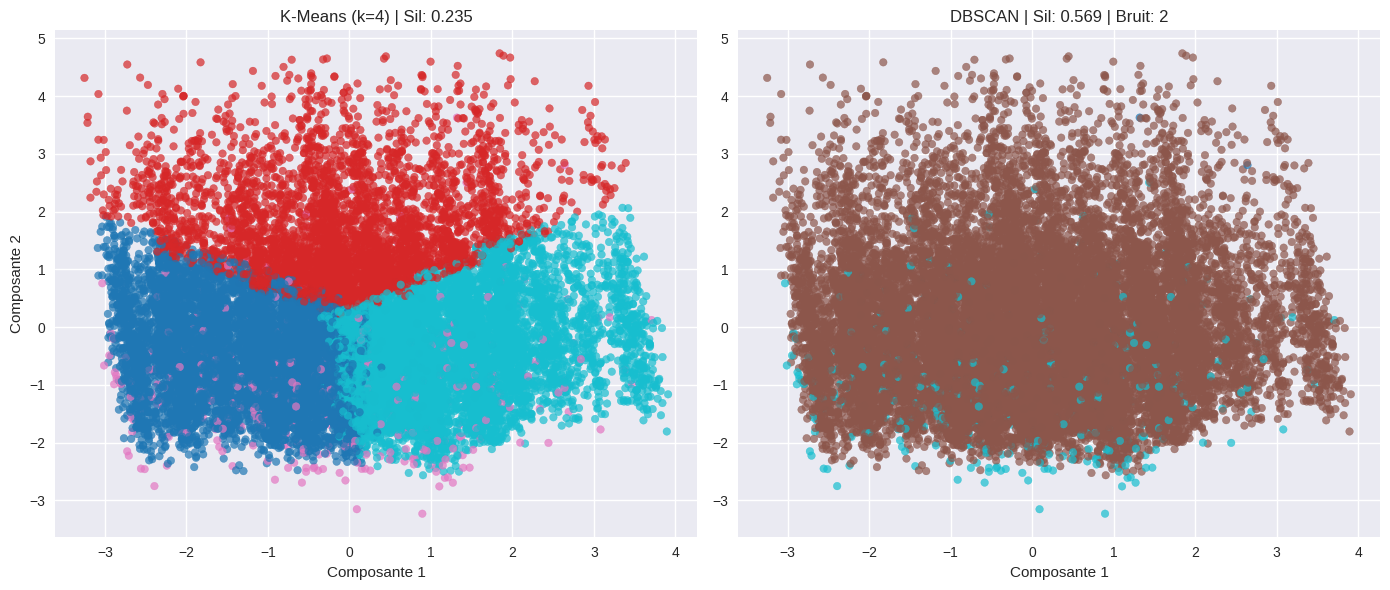

In [75]:
# ========================================
# COMPARAISON K-MEANS vs DBSCAN (SANS ERREUR)
# ========================================
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# 1. PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_clustering)

# 2. K-MEANS (CORRIGÉ EN FLOAT)
labels_kmeans = data['segment'].astype(float).values  # ← FLOAT
sil_kmeans = silhouette_score(X_clustering, labels_kmeans)

# 3. DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_clustering)
labels_dbscan = np.array(labels_dbscan, dtype=float)  # ← FLOAT

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = np.sum(labels_dbscan == -1)
sil_dbscan = silhouette_score(X_clustering, labels_dbscan) if n_clusters_dbscan > 1 else -1

# 4. VISUALISATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='tab10', s=30, alpha=0.7)
ax1.set_title(f"K-Means (k=4) | Sil: {sil_kmeans:.3f}")
ax1.set_xlabel("Composante 1")
ax1.set_ylabel("Composante 2")

# DBSCAN
colors_db = np.where(labels_dbscan == -1, -1, labels_dbscan)  # bruit = -1
cmap_db = plt.cm.tab10
cmap_db = cmap_db(np.arange(cmap_db.N))
cmap_db[0] = [0.7, 0.7, 0.7, 1]  # gris pour bruit
ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_db, cmap='tab10', s=30, alpha=0.7)
ax2.set_title(f"DBSCAN | Sil: {sil_dbscan:.3f} | Bruit: {int(n_noise)}")
ax2.set_xlabel("Composante 1")

plt.tight_layout()
plt.show()